In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
 
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
 
import torch
from datasets import DatasetDict, Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
import evaluate
import pickle
from datasets import load_from_disk
import optuna

warnings.filterwarnings("ignore")

In [2]:
encoded_dataset = load_from_disk("title_classifier_encoded_dataset_distrilroberta.hf")  
# encoded_dataset.set_format("torch")

In [3]:
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(device)

mps


In [4]:
encoded_dataset.set_format("torch", device=device)

## Load the Encoder

In [5]:
import pickle
with open("/Users/philip.juachon/Desktop/Personal Learning/Deep Learning/final-project/artifacts/02_y_encoder.pkl", "rb") as f:
    y_encoder = pickle.load(f)

## Define Hyperparameter Tuning Helpers

In [6]:
def model_init():
    return AutoModelForSequenceClassification.from_pretrained(
        "distilbert-base-uncased", 
        num_labels=NUM_LABELS,
        id2label=id2label,
        label2id=label2id
    )

In [7]:
# def optuna_hp_space(trial):
#     return {
#         # Explore learning rates between 1e-5 and 5e-5 (logarithmic scale)
#         "learning_rate": trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True),
#         # Test batch sizes of 16 vs 32
#         "per_device_train_batch_size": trial.suggest_categorical("per_device_train_batch_size", [16, 32]),
#         # Explore how much weight decay (regularization) helps
#         "weight_decay": trial.suggest_float("weight_decay", 0.0, 0.1),
#     }

In [8]:
def optuna_hp_space(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True),
        "per_device_train_batch_size": trial.suggest_categorical("per_device_train_batch_size", [16, 32]),
        "weight_decay": trial.suggest_float("weight_decay", 0.0, 0.1),
        
        "warmup_ratio": trial.suggest_float("warmup_ratio", 0.0, 0.2),
        "lr_scheduler_type": trial.suggest_categorical("lr_scheduler_type", ["linear", "cosine"])
    }

## Sample the data

In [9]:
tune_train_data = encoded_dataset["train"].shuffle(seed=42).select(range(10000))
tune_eval_data = encoded_dataset["validation"].shuffle(seed=42).select(range(2000))

## Finetuning Proper

In [10]:
labels = y_encoder.classes_
id2label = {idx: label for idx, label in enumerate(labels)}
label2id = {label: idx for idx, label in enumerate(labels)}
NUM_LABELS = len(labels)

In [11]:
def compute_metrics(eval_pred):
    logits, true_labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    
    f1 = f1_score(true_labels, predictions, average='weighted')
    acc = accuracy_score(true_labels, predictions)
    return {"accuracy": acc, "f1": f1}

In [13]:
training_args = TrainingArguments(
    output_dir="./results_tuning",
    eval_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=2,              # Keep epochs low for the search phase!
    per_device_eval_batch_size=32,
    logging_steps=50,
    disable_tqdm=True,               # Turn off progress bars so it doesn't flood your screen
)

In [14]:
trainer = Trainer(
    model_init=model_init,           # Use the function, not the model!
    args=training_args,
    train_dataset=tune_train_data,   # Use the mini dataset!
    eval_dataset=tune_eval_data,
    compute_metrics=compute_metrics,
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [15]:
print("Starting Optuna Hyperparameter Search...")
best_trial = trainer.hyperparameter_search(
    direction="maximize",            # We want to MAXIMIZE the F1 score
    backend="optuna",
    hp_space=optuna_hp_space,
    n_trials=5                       # Try 5 different combinations
)

[I 2026-03-29 09:11:42,224] A new study created in memory with name: no-name-db5b4d37-48ec-4763-91c1-fafa051015ec


Starting Optuna Hyperparameter Search...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'loss': '2.871', 'grad_norm': '3.4', 'learning_rate': '3.362e-05', 'epoch': '0.08'}
{'loss': '2.393', 'grad_norm': '5.838', 'learning_rate': '3.323e-05', 'epoch': '0.16'}
{'loss': '2.096', 'grad_norm': '7.977', 'learning_rate': '3.258e-05', 'epoch': '0.24'}
{'loss': '1.775', 'grad_norm': '9.334', 'learning_rate': '3.168e-05', 'epoch': '0.32'}
{'loss': '1.73', 'grad_norm': '7.734', 'learning_rate': '3.055e-05', 'epoch': '0.4'}
{'loss': '1.511', 'grad_norm': '6.005', 'learning_rate': '2.92e-05', 'epoch': '0.48'}
{'loss': '1.473', 'grad_norm': '11.78', 'learning_rate': '2.766e-05', 'epoch': '0.56'}
{'loss': '1.54', 'grad_norm': '15.27', 'learning_rate': '2.595e-05', 'epoch': '0.64'}
{'loss': '1.378', 'grad_norm': '8.572', 'learning_rate': '2.41e-05', 'epoch': '0.72'}
{'loss': '1.402', 'grad_norm': '8.281', 'learning_rate': '2.213e-05', 'epoch': '0.8'}
{'loss': '1.319', 'grad_norm': '14.86', 'learning_rate': '2.008e-05', 'epoch': '0.88'}
{'loss': '1.269', 'grad_norm': '10.64', 'learning_r

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '1.687', 'grad_norm': '5.556', 'learning_rate': '5.903e-06', 'epoch': '1.04'}
{'loss': '1.618', 'grad_norm': '9.635', 'learning_rate': '5.412e-06', 'epoch': '1.12'}
{'loss': '1.541', 'grad_norm': '8.396', 'learning_rate': '4.921e-06', 'epoch': '1.2'}
{'loss': '1.548', 'grad_norm': '7.128', 'learning_rate': '4.43e-06', 'epoch': '1.28'}
{'loss': '1.516', 'grad_norm': '6.307', 'learning_rate': '3.939e-06', 'epoch': '1.36'}
{'loss': '1.46', 'grad_norm': '7.524', 'learning_rate': '3.447e-06', 'epoch': '1.44'}
{'loss': '1.472', 'grad_norm': '7.735', 'learning_rate': '2.956e-06', 'epoch': '1.52'}
{'loss': '1.425', 'grad_norm': '6.219', 'learning_rate': '2.465e-06', 'epoch': '1.6'}
{'loss': '1.481', 'grad_norm': '8.237', 'learning_rate': '1.974e-06', 'epoch': '1.68'}
{'loss': '1.425', 'grad_norm': '9.339', 'learning_rate': '1.483e-06', 'epoch': '1.76'}
{'loss': '1.383', 'grad_norm': '7.039', 'learning_rate': '9.92e-07', 'epoch': '1.84'}
{'loss': '1.443', 'grad_norm': '13.97', 'learnin

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '915.6', 'train_samples_per_second': '21.84', 'train_steps_per_second': '1.365', 'train_loss': '1.831', 'epoch': '2'}


[I 2026-03-29 10:27:44,283] Trial 4 finished with value: 1.2056105014757832 and parameters: {'learning_rate': 1.2277257414565191e-05, 'per_device_train_batch_size': 16, 'weight_decay': 0.09646858353196751, 'warmup_ratio': 0.18442177130590745, 'lr_scheduler_type': 'linear'}. Best is trial 0 with value: 1.36021037401523.


In [16]:
print("\n--- TUNING COMPLETE ---")
print(f"Best F1 Score Achieved: {best_trial.objective}")
print(f"Winning Hyperparameters: {best_trial.hyperparameters}")


--- TUNING COMPLETE ---
Best F1 Score Achieved: 1.36021037401523
Winning Hyperparameters: {'learning_rate': 3.3746216420201576e-05, 'per_device_train_batch_size': 16, 'weight_decay': 0.0903275294919926, 'warmup_ratio': 0.11484769148235374, 'lr_scheduler_type': 'cosine'}


## Fine tuning proper

In [18]:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", 
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id
)

model = model.to(device)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [22]:
WEIGHT_DECAY = 0.0903275294919926
SEED = 69
BATCH_SIZE = 16
EPOCHS = 5
LEARNING_RATE = 3.3746216420201576e-05
LOGGING_STEPS = 50
WARMUP_RATIO = 0.11484769148235374
LR_SCHEDULER_TYPE = 'cosine'

training_args = TrainingArguments(
    output_dir="/Users/philip.juachon/Desktop/Personal Learning/Deep Learning/final-project/output/results_finetuned_distilroberta_headlinesanddescriptions",
    learning_rate=LEARNING_RATE,              
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    num_train_epochs=EPOCHS,              
    weight_decay = WEIGHT_DECAY,
    seed = SEED,
    logging_steps = LOGGING_STEPS,
    eval_strategy="epoch",     
    save_strategy="epoch",           
    load_best_model_at_end=True,     
    metric_for_best_model="f1",
    warmup_ratio=WARMUP_RATIO,
    lr_scheduler_type=LR_SCHEDULER_TYPE
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [23]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["validation"],
    compute_metrics=compute_metrics
)

In [24]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.932976,0.873746,0.744636,0.741146
2,0.729369,0.827451,0.760635,0.753801
3,0.498341,0.880645,0.764480,0.763483
4,0.256758,1.066684,0.762867,0.760843
5,0.147548,1.173709,0.761658,0.760075


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=40315, training_loss=0.5662166438859109, metrics={'train_runtime': 29978.6915, 'train_samples_per_second': 21.516, 'train_steps_per_second': 1.345, 'total_flos': 4.27402467571968e+16, 'train_loss': 0.5662166438859109, 'epoch': 5.0})

In [25]:
print("\nEvaluating on Test Set...")
print(trainer.evaluate(encoded_dataset["test"]))


Evaluating on Test Set...


{'eval_loss': 0.878058910369873, 'eval_accuracy': 0.763934019595684, 'eval_f1': 0.762673916814471, 'eval_runtime': 474.6406, 'eval_samples_per_second': 84.938, 'eval_steps_per_second': 2.655, 'epoch': 5.0}


In [26]:
test_output = trainer.predict(encoded_dataset["test"])
predictions = np.argmax(test_output.predictions, axis=-1)
print(predictions)

[14 16  6 ... 14 16 22]


In [27]:
print(f"\n── Test set evaluation Headline + Short Description) ──")
test_output = trainer.predict(encoded_dataset["test"])
preds = np.argmax(test_output.predictions, axis=-1)


── Test set evaluation Headline + Short Description) ──


In [28]:
labels = test_output.label_ids

In [29]:
labels

array([14, 16,  6, ..., 12, 16, 22])

In [30]:
report = classification_report(
    labels, preds,
    target_names=y_encoder.classes_,
    digits=4,
    zero_division=0,
)
print(report)

                precision    recall  f1-score   support

ARTS & CULTURE     0.6179    0.6684    0.6422       784
  BLACK VOICES     0.5954    0.5044    0.5461       916
      BUSINESS     0.6249    0.6882    0.6550      1549
        COMEDY     0.6247    0.5250    0.5706      1078
         CRIME     0.6340    0.6653    0.6493       711
       DIVORCE     0.8060    0.8260    0.8159       684
 ENTERTAINMENT     0.7726    0.7918    0.7821      3472
   ENVIRONMENT     0.6114    0.6589    0.6343       812
  FOOD & DRINK     0.8488    0.8554    0.8521      1687
 HOME & LIVING     0.8310    0.8368    0.8339       858
        IMPACT     0.4886    0.4296    0.4572       696
         MEDIA     0.6793    0.5476    0.6064       588
     PARENTING     0.8213    0.7587    0.7887      2532
      POLITICS     0.8411    0.8405    0.8408      7117
  QUEER VOICES     0.8074    0.7762    0.7915      1269
      RELIGION     0.6487    0.6323    0.6404       514
SCIENCE & TECH     0.5679    0.6479    0.6053  

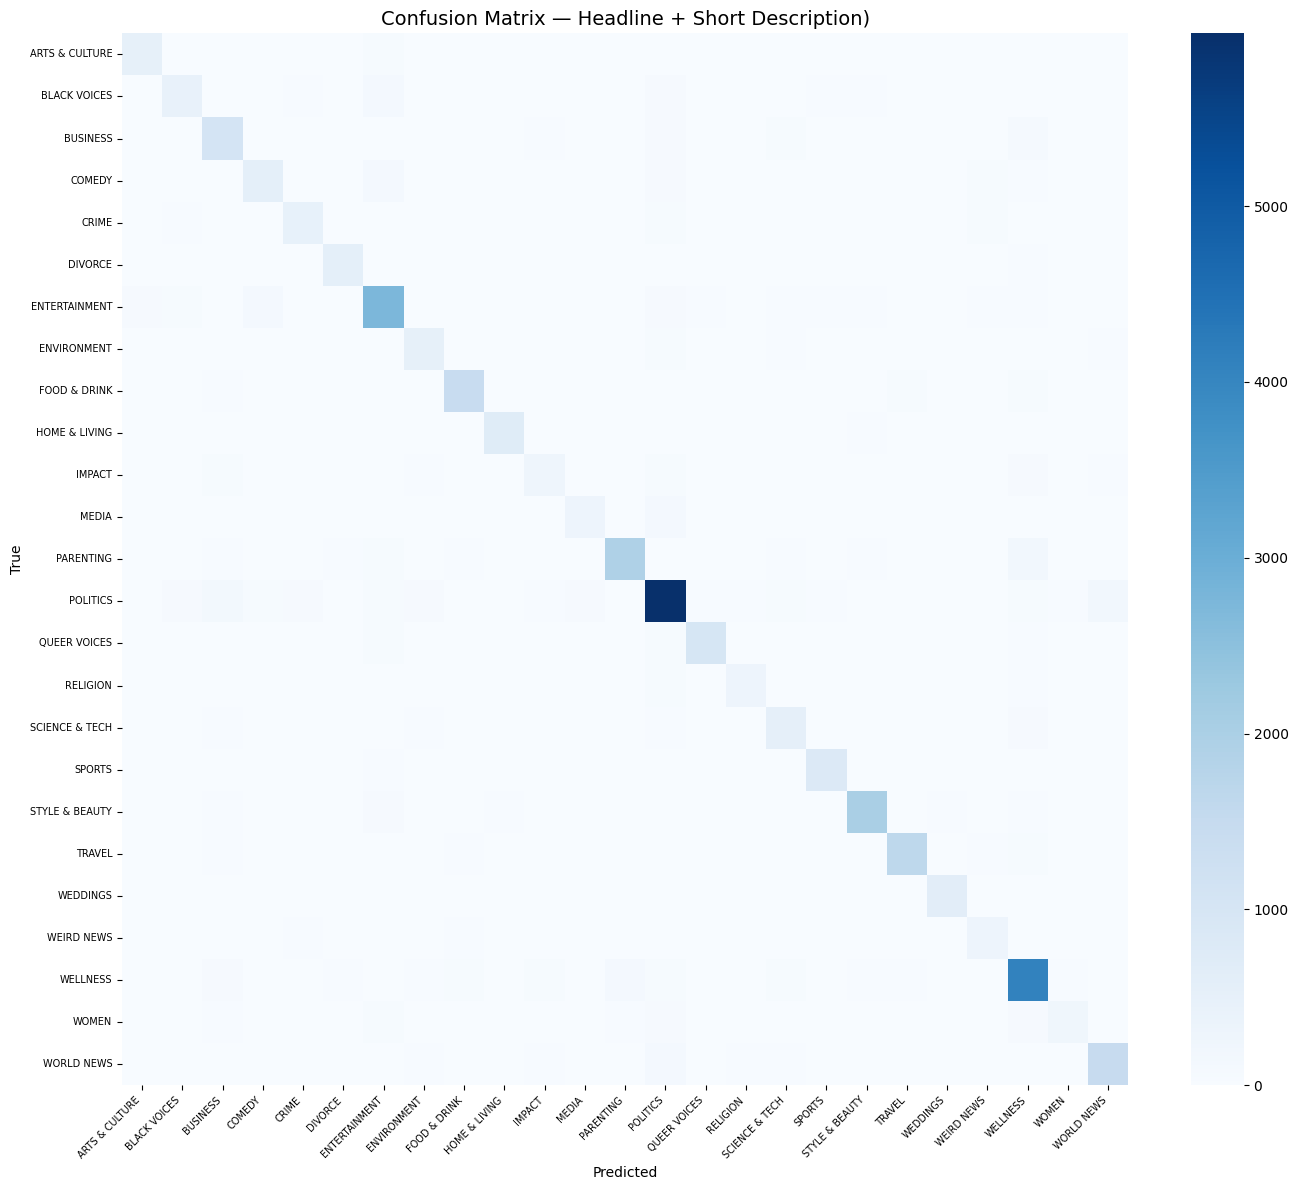

In [31]:
cm = confusion_matrix(labels, preds)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm, annot=False, fmt='d', cmap='Blues',
    xticklabels=y_encoder.classes_, yticklabels=y_encoder.classes_, ax=ax
)
ax.set_title(f"Confusion Matrix — Headline + Short Description)", fontsize=14)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()